# GPT-1
## Transformer 대비 GPT-1 아키텍처 변경 사항

GPT-1은 기존 Transformer의 인코더-디코더 구조에서 인코더를 완전히 제거하고,  
디코더의 내부 구조를 자기회귀(Auto-regressive) 학습에 적합하게 수정하였습니다.

- Encoder 제거:  
질문을 압축하던 Encoder가 사라졌습니다. 대신 질문과 답변을 하나의 시퀀스로 묶어 입력합니다.

- Encoder-Decoder Attention 제거:  
인코더가 없으므로, 디코더 블록 내에서 인코더의 출력을 참조하던 'Multi-Head Attention' 레이어가 삭제되었습니다. 오직 Self-Attention만 남습니다.

- Positional Encoding의 변화:  
사인/코사인 함수를 이용한 고정 방식 대신, 모델이 위치 정보를 직접 학습하는 Learned Positional Embedding을 채택하였습니다.

- 단일 시퀀스 입력 구조:  
[START] + 질문 + [SEP] + 답변 + [END] 형태의 단일 벡터가 모델을 통과하며 다음 토큰을 예측합니다.

![img](img/tf2gpt.png) 


## import

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.nn.utils.rnn import pad_sequence
from torchinfo import summary
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import pandas as pd


## Attention
### Scaled Dot Product Attention

In [2]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

### Multihead Attention

내부적으로는 Scaled Dot Product Attention 함수를 호출

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


## Masking
### Padding Masking  
정해준 길이보다 짧은 문장의 경우에는 숫자 0을 채워서 문장의 길이를 맞춰줌

In [4]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [5]:
x = torch.tensor([[1, 2, 0, 3, 0],
                  [0, 0, 0, 4, 5]])
mask = create_padding_mask(x)
print("입력 텐서 크기 :", x.shape)    # (2, 5)
print("생성된 마스크 크기 :", mask.shape)  # (2, 1, 1, 5)
print(mask)

입력 텐서 크기 : torch.Size([2, 5])
생성된 마스크 크기 : torch.Size([2, 1, 1, 5])
tensor([[[[0., 0., 1., 0., 1.]]],


        [[[1., 1., 1., 0., 0.]]]])


### Look-ahead Masking
다음 단어 가리기. create_padding_mask 호출

In [6]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [7]:
x = torch.tensor([[1, 2, 3, 4, 5]])
mask_1 = create_look_ahead_mask(x)
print("첫 번째 시퀀스:\n", mask_1, mask_1.shape)

첫 번째 시퀀스:
 tensor([[[[0., 1., 1., 1., 1.],
          [0., 0., 1., 1., 1.],
          [0., 0., 0., 1., 1.],
          [0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [8]:
x2 = torch.tensor([[0, 5, 1, 5, 5]])
mask_2 = create_look_ahead_mask(x2)
print("두 번째 시퀀스:\n", mask_2, mask_2.shape)

두 번째 시퀀스:
 tensor([[[[1., 1., 1., 1., 1.],
          [1., 0., 1., 1., 1.],
          [1., 0., 0., 1., 1.],
          [1., 0., 0., 0., 1.],
          [1., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


## Decoder
### Decoder Layer for GPT-1

In [9]:

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # [GPT-1 변경] 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션) - 유지
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # [GPT-1 변경] 두 번째 서브 레이어 (인코더-디코더 어텐션) - 삭제
        #self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        #self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # [GPT-1 변경] 세 번째 서브 레이어 (피드포워드 네트워크) - 유지 (인덱스 조정)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6) # 인코더 어텐션이 빠졌으므로 norm2로 명명

        # 드롭아웃 (2개만 필요)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        #self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # GPT-1은 enc_outputs와 padding_mask(인코더용)를 받지 않습니다.

        # 1) 셀프 어텐션 (Masked Self-Attention) - 유지
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) [GPT-1 변경] 인코더-디코더 어텐션 - 삭제
        #encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        #encdec_attn_out = self.dropout2(encdec_attn_out)
        #out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (FFN) - 유지 (인덱스 조정)
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        out2 = self.norm2(out1 + ffn_out)  # 잔차 연결 + LayerNorm

        return out2

### Decoder Layer 을 쌓아 Decoder 생성

In [10]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1,
                 max_len=512):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 토큰 임베딩 레이어 (W_e)
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) [GPT-1 변경] 학습 가능한 위치 임베딩 레이어 (W_p)
        # 고정된 함수(포지셔널 인코딩) 대신 nn.Embedding을 사용합니다.
        self.pos_embedding = nn.Embedding(max_len, d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])



    def forward(self, x, look_ahead_mask=None):
        """
        GPT-1은 Decoder-only 구조이므로 인코더와 관련된 
        enc_outputs, padding_mask 인자를 모두 제거하였습니다.
        오직 현재 입력된 시퀀스(x)와 미래 단어를 가리는 look_ahead_mask만 사용합니다.

        look_ahead_mask: [batch_size, 1, seq_len, seq_len] (미래 토큰 차단용)
        """

        # x: [batch_size, seq_len] (토큰 ID들의 시퀀스)
        batch_size, seq_len = x.size()

        # (1) 위치 인덱스 생성 (0, 1, 2, ..., seq_len-1)
        # 0부터 seq_len-1까지의 숫자를 생성하여 각 토큰의 위치를 나타냅니다.
        # x.device를 사용하여 GPU 학습 시 텐서 위치를 맞춥니다.
        pos = torch.arange(0, seq_len).unsqueeze(0).repeat(batch_size, 1).to(x.device)

        # (2) 입력 블록 구성
        # Token Embedding(We)과 학습 가능한 Position Embedding(Wp)을 더합니다.
        # h0 = UWe + Wp
        x = self.embedding(x) + self.pos_embedding(pos)
        x = self.dropout(x)

        # (3) GPT 디코더 레이어 적층 통과
        # 인코더 출력(enc_outputs) 없이 자기 자신의 문맥만 참조합니다.
        for layer in self.dec_layers:
            x = layer(x, look_ahead_mask)

        # 최종 특징 벡터 반환 
        # (만약 GPT 클래스에서 final_linear를 처리한다면 여기서 x를 반환합니다)
        return x


## GPT
### GPT-1 클래스 정의

In [11]:
class GPT(nn.Module): # Transformer 대신 GPT라는 이름을 사용
    def __init__(self, 
                 vocab_size, 
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1, 
                 max_len=512):
        super(GPT, self).__init__()

        # [변경] 인코더는 생성하지 않습니다.
        # self.encoder = Encoder(...) <- 삭제
        
        # [변경] 디코더만 생성합니다. 
        # 위에서 만든 '학습 가능한 위치 임베딩'이 포함된 Decoder를 호출합니다.
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout,
            max_len=max_len
        )

        # 최종 출력층 (Next Token Prediction용)
        # Decoder 클래스 내부에 구현했다면 여기서 생략 가능, 
        # 가독성을 위해 여기서 정의한다면 Decoder는 특징 추출(d_model)까지만 수행합니다.
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, dec_inputs): 
        # [GPT 변경] 인자인 inputs(인코더용) 제거
        
        # 1) 디코더용 look-ahead 마스크만 생성
        look_ahead_mask = create_look_ahead_mask(dec_inputs)

        # 2) 디코더 수행 (인코더 출력인 enc_outputs 전달 과정 삭제)
        dec_outputs = self.decoder(
            x=dec_inputs, 
            look_ahead_mask=look_ahead_mask
        )

        # 3) 최종 로짓 생성
        logits = self.final_linear(dec_outputs)
        return logits

## 데이터 구조 생성
### 데이터 로드

In [12]:
# 1. 데이터 로드
file_path = 'chatbot_data/ChatbotData.csv'
train_data = pd.read_csv(file_path)

# 2. 질문과 답변 리스트 생성
questions = train_data['Q'].tolist()
answers = train_data['A'].tolist()

print(f"전체 데이터 개수: {len(questions)}")
print("Q:", questions[0])
print("A:", answers[0])

전체 데이터 개수: 11823
Q: 12시 땡!
A: 하루가 또 가네요.


In [13]:
# 사용할 샘플의 최대 개수
MAX_SAMPLES = len(questions) # 전체 사용
print(MAX_SAMPLES)

11823


### 한국어 전처리 함수

In [14]:
# 한국어 전처리 함수
def preprocess_sentence(sentence):
    # 양쪽 공백 제거
    sentence = sentence.strip()
    
    # 단어와 구두점(.,!?) 사이의 거리를 만듭니다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 한글, 알파벳, 숫자, 구두점을 제외한 모든 문자를 공백으로 대체합니다.
    sentence = re.sub(r"[^a-zA-Z0-9가-힣?.!,]+", " ", sentence)
    
    return sentence.strip()

In [15]:
# 전처리 테스트

sample_sentence = "안녕하세요? Hello! I'm a student😊, sns ㅋㅋㅋㅋ! 1q2w3e4r!"
print(preprocess_sentence(sample_sentence)) 

안녕하세요 ? Hello ! I m a student , sns ! 1q2w3e4r !


## 데이터 전처리
### 질문(Q)과 답변(A)을 하나로 합치는 명제추론 전처리

 ![img](img/entailment.png)  
 코드에서는 [START] {q} [SEP] {a} [END] 구조 사용

In [16]:
# GPT-1용 최종 데이터 구성 함수
def prepare_gpt_data(questions, answers):
    processed_inputs = []
    
    for q, a in zip(questions, answers):
        # 1. 한국어 기본 정제
        q = preprocess_sentence(q)
        a = preprocess_sentence(a)
        
        # 2. GPT-1 논문 Figure 1의 구조 적용 (Task-specific Input Transformation)
        # [START] 질문 [SEP] 답변 [END]
        gpt_input = f"[START] {q} [SEP] {a} [END]"
        processed_inputs.append(gpt_input)
        
    return processed_inputs

In [17]:
# 실행
gpt_formatted_data = prepare_gpt_data(questions, answers)
# 20개 출력
for i in range(20):
    print(f"{i:2d}: {gpt_formatted_data[i]}")

 0: [START] 12시 땡 ! [SEP] 하루가 또 가네요 . [END]
 1: [START] 1지망 학교 떨어졌어 [SEP] 위로해 드립니다 . [END]
 2: [START] 3박4일 놀러가고 싶다 [SEP] 여행은 언제나 좋죠 . [END]
 3: [START] 3박4일 정도 놀러가고 싶다 [SEP] 여행은 언제나 좋죠 . [END]
 4: [START] PPL 심하네 [SEP] 눈살이 찌푸려지죠 . [END]
 5: [START] SD카드 망가졌어 [SEP] 다시 새로 사는 게 마음 편해요 . [END]
 6: [START] SD카드 안돼 [SEP] 다시 새로 사는 게 마음 편해요 . [END]
 7: [START] SNS 맞팔 왜 안하지 [SEP] 잘 모르고 있을 수도 있어요 . [END]
 8: [START] SNS 시간낭비인 거 아는데 매일 하는 중 [SEP] 시간을 정하고 해보세요 . [END]
 9: [START] SNS 시간낭비인데 자꾸 보게됨 [SEP] 시간을 정하고 해보세요 . [END]
10: [START] SNS보면 나만 빼고 다 행복해보여 [SEP] 자랑하는 자리니까요 . [END]
11: [START] 가끔 궁금해 [SEP] 그 사람도 그럴 거예요 . [END]
12: [START] 가끔 뭐하는지 궁금해 [SEP] 그 사람도 그럴 거예요 . [END]
13: [START] 가끔은 혼자인게 좋다 [SEP] 혼자를 즐기세요 . [END]
14: [START] 가난한 자의 설움 [SEP] 돈은 다시 들어올 거예요 . [END]
15: [START] 가만 있어도 땀난다 [SEP] 땀을 식혀주세요 . [END]
16: [START] 가상화폐 쫄딱 망함 [SEP] 어서 잊고 새출발 하세요 . [END]
17: [START] 가스불 켜고 나갔어 [SEP] 빨리 집에 돌아가서 끄고 나오세요 . [END]
18: [START] 가스불 켜놓고 나온거 같아 [SEP] 빨리 집에 돌아가서 끄고 나오세요 . [END]
19: [START] 가스비 너

### corpus 생성  
기본적인 질문/답변만 저장했던 이전 방식과 달리,  
GPT-1은 특수 토큰([START], [SEP], [END]) 사이의 관계를 학습하는 것이 핵심입니다.  
토크나이저(SentencePiece)가 이 특수 토큰들을 하나의 단위로 완벽하게 인식하게 하려면,  
학습용 코퍼스 파일 자체에 이 토큰들이 포함되어 있어야 합니다.

In [18]:
# 이미 생성해둔 gpt_formatted_data를 사용합니다.
# gpt_formatted_data = ["[START] 질문 [SEP] 답변 [END]", ...]

corpus_file = 'chatbot_gpt_corpus.txt'

with open(corpus_file, 'w', encoding='utf-8') as f:
    for line in gpt_formatted_data:
        f.write(line + '\n')

print(f"GPT-1 전용 코퍼스 생성 완료! (데이터 개수: {len(gpt_formatted_data)})")

GPT-1 전용 코퍼스 생성 완료! (데이터 개수: 11823)


### SentencePiece 토크나이저 학습

In [19]:
corpus_file = 'chatbot_gpt_corpus.txt'
model_prefix = 'tokenizer'

# SentencePiece 학습 (함수 인자 방식)
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix=model_prefix,
    vocab_size=8000,
    character_coverage=1.0,         # 한글 처리를 위해 1.0 설정
    model_type="bpe",               # BPE 알고리즘 적용
    max_sentence_length=2000,       # 문장 최대 길이
    bos_id=1,                       # <s> 설정 (필요시 내부적으로 사용)
    eos_id=2,                       # </s> 설정
    pad_id=0,                       # <pad> 설정
    unk_id=3,                       # <unk> 설정
    user_defined_symbols="[START],[SEP],[END]" # GPT-1 특수 토큰 등록
)

print(f"한국어 토크나이저 학습 완료: {model_prefix}.model")


한국어 토크나이저 학습 완료: tokenizer.model


In [20]:
sp = spm.SentencePieceProcessor()
sp.Load("tokenizer.model")

True

In [21]:
# Test Code

# GPT-1 논문의 Entailment 구조: [START] Premise [SEP] Hypothesis [END]
# 데이터에 대입: [START] Question [SEP] Answer [END]

test_pairs = [
    {"premise": "SNS 보면 나만 빼고 다 행복해 보여.", "hypothesis": "자랑해서 그래요."},
    {"premise": "3박 4일 정도 놀러가고 싶다!", "hypothesis": "여행은 언제나 좋죠."},
    {"premise": "SD카드 망가졌어.", "hypothesis": "다시 새로 사는 게 마음 편해요."}
]

print("=== GPT-1 논문 양식 (Premise + Hypothesis) 테스트 ===\n")

for pair in test_pairs:
    # 1. 전처리 적용
    p = preprocess_sentence(pair['premise'])
    h = preprocess_sentence(pair['hypothesis'])
    
    # 2. 논문 Figure 1의 Input Transformation 적용
    gpt_input = f"[START] {p} [SEP] {h} [END]"
    
    # 3. 토크나이징 및 인코딩
    tokens = sp.encode(gpt_input, out_type=str)
    encoded = sp.encode(gpt_input, out_type=int)
    decoded = sp.decode(encoded)
    
    print(f"[Premise]   : {pair['premise']}")
    print(f"[Hypothesis]: {pair['hypothesis']}")
    print(f"GPT Input   : {gpt_input}")
    print(f"Tokens      : {tokens}")
    print(f"Encoded     : {encoded}")
    print(f"Decoded     : {decoded}")
    print("-" * 80)


=== GPT-1 논문 양식 (Premise + Hypothesis) 테스트 ===

[Premise]   : SNS 보면 나만 빼고 다 행복해 보여.
[Hypothesis]: 자랑해서 그래요.
GPT Input   : [START] SNS 보면 나만 빼고 다 행복해 보여 . [SEP] 자랑해서 그래요 . [END]
Tokens      : ['▁', '[START]', '▁SNS', '▁보면', '▁나만', '▁빼고', '▁다', '▁행복해', '▁보여', '▁.', '▁', '[SEP]', '▁자', '랑', '해서', '▁그래요', '▁.', '▁', '[END]']
Encoded     : [6770, 4, 1925, 1242, 474, 4163, 29, 1157, 1037, 7, 6770, 5, 41, 6806, 309, 1400, 7, 6770, 6]
Decoded     : [START] SNS 보면 나만 빼고 다 행복해 보여 . [SEP] 자랑해서 그래요 . [END]
--------------------------------------------------------------------------------
[Premise]   : 3박 4일 정도 놀러가고 싶다!
[Hypothesis]: 여행은 언제나 좋죠.
GPT Input   : [START] 3박 4일 정도 놀러가고 싶다 ! [SEP] 여행은 언제나 좋죠 . [END]
Tokens      : ['▁', '[START]', '▁3', '박', '▁4', '일', '▁정도', '▁놀러가고', '▁싶다', '▁!', '▁', '[SEP]', '▁여행은', '▁언제나', '▁좋죠', '▁.', '▁', '[END]']
Encoded     : [6770, 4, 478, 7278, 945, 6820, 986, 3496, 204, 111, 6770, 5, 5128, 1361, 385, 7, 6770, 6]
Decoded     : [START] 3박 4일 정도 놀러가고 싶다 ! [SEP] 여행은

### Dataset 구현

In [22]:
class ChatbotDataset(Dataset):
    def __init__(self, formatted_data, sp_processor, max_len=128):
        # [START] Q [SEP] A [END] 로 합쳐진 리스트를 받습니다.
        self.sentences = formatted_data  
        self.sp = sp_processor  # 학습시킨 SentencePiece 모델
        self.max_len = max_len  # 최대 문장 길이

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        # 1. 이미 포맷팅된 문장을 가져와 인코딩
        full_text = self.sentences[idx]
        ids = self.sp.encode_as_ids(full_text)

        # 2. 최대 길이 제한 (max_len)
        if len(ids) > self.max_len:
            ids = ids[:self.max_len]
        
        # 3. GPT 학습용 입출력 생성 (한 칸 Shift)
        # input:  [START] ... [SEP] ... (마지막 토큰 제외)
        # target: [START] 다음 토큰 ... [END] (첫 번째 토큰 제외)
        curr_input = torch.tensor(ids[:-1], dtype=torch.long)
        curr_target = torch.tensor(ids[1:], dtype=torch.long)
        
        return {
            'input_ids': curr_input,
            'target_ids': curr_target
        }

# GPT-1용 동적 패딩 처리 함수
def collate_fn(batch):
    # 각 배치의 길이에 맞춰 가장 긴 문장 기준으로 0(Padding)을 채웁니다.
    input_ids = pad_sequence([item['input_ids'] for item in batch], batch_first=True, padding_value=0)
    target_ids = pad_sequence([item['target_ids'] for item in batch], batch_first=True, padding_value=0)
    
    return input_ids, target_ids

In [23]:
# 하이퍼파라미터 설정
MAX_LEN = 128    # 문장의 최대 길이 (메모리 상황에 따라 조절)
BATCH_SIZE = 64 # 한 번에 학습할 데이터 묶음 크기

In [24]:
# 인스턴스 생성
dataset = ChatbotDataset(
    formatted_data=gpt_formatted_data, 
    sp_processor=sp, 
    max_len=MAX_LEN
)

### DataLoader 구성

In [25]:
# DataLoader 연결
dataloader = DataLoader(
    dataset, 
    batch_size=64, 
    shuffle=True, 
    collate_fn=collate_fn
)

In [26]:
# Test Code
for input_ids, target_ids in dataloader:
    print("--- GPT-1 배치 텐서 정보 ---")
    print("입력(Input) 크기  :", input_ids.size())  # [64, 현재 배치 최장 길이]
    print("정답(Target) 크기 :", target_ids.size()) # [64, 현재 배치 최장 길이]
    
    print("\n--- 실제 데이터 샘플 (첫 번째 문장) ---")
    
    # 모델 입력 (START + Q + SEP + A)
    print("Input IDs (Raw):\n", input_ids[0])
    print("Decoded Input:", sp.decode(input_ids[0].tolist()))
    
    # 모델 정답 (Q + SEP + A + END)
    print("\nTarget IDs (Raw):\n", target_ids[0])
    print("Decoded Target:", sp.decode(target_ids[0].tolist()))
    
    # 한 칸 밀림(Shift) 검증
    print("\n--- Shift 검증 (첫 5개 토큰) ---")
    print("Input  Tokens:", input_ids[0][:5].tolist())
    print("Target Tokens:", target_ids[0][:5].tolist())
    print(">> Target은 Input의 [1:] 인덱스와 일치해야 합니다.")
    
    break # 한 배치만 확인하고 종료

--- GPT-1 배치 텐서 정보 ---
입력(Input) 크기  : torch.Size([64, 25])
정답(Target) 크기 : torch.Size([64, 25])

--- 실제 데이터 샘플 (첫 번째 문장) ---
Input IDs (Raw):
 tensor([6770,    4, 2282,  242, 6896, 5791, 3607,  305,   14, 6770,    5,  591,
        5735,   34,  455, 5309,    7, 6770,    0,    0,    0,    0,    0,    0,
           0])
Decoded Input: [START] 언제쯤 편히 잠들수있을까 ? [SEP] 생각을 안할 수 있으면 좋으련만 . 

Target IDs (Raw):
 tensor([   4, 2282,  242, 6896, 5791, 3607,  305,   14, 6770,    5,  591, 5735,
          34,  455, 5309,    7, 6770,    6,    0,    0,    0,    0,    0,    0,
           0])
Decoded Target: [START] 언제쯤 편히 잠들수있을까 ? [SEP] 생각을 안할 수 있으면 좋으련만 . [END]

--- Shift 검증 (첫 5개 토큰) ---
Input  Tokens: [6770, 4, 2282, 242, 6896]
Target Tokens: [4, 2282, 242, 6896, 5791]
>> Target은 Input의 [1:] 인덱스와 일치해야 합니다.


## 모델 생성 및 학습

### 모델 생성

In [27]:
# 예: 하이퍼파라미터 설정
NUM_LAYERS = 4     # 디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000  # 단어 집합 크기

# 모델 생성
model = GPT(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
    max_len=MAX_LEN
)

print(model)

GPT(
  (decoder): Decoder(
    (embedding): Embedding(8000, 256)
    (pos_embedding): Embedding(128, 256)
    (dropout): Dropout(p=0.1, inplace=False)
    (dec_layers): ModuleList(
      (0-3): 4 x DecoderLayer(
        (self_mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=

In [28]:
summary(model, input_size=(1, MAX_LEN), dtypes=[torch.long])

Layer (type:depth-idx)                        Output Shape              Param #
GPT                                           [1, 128, 8000]            --
├─Decoder: 1-1                                [1, 128, 256]             --
│    └─Embedding: 2-1                         [1, 128, 256]             2,048,000
│    └─Embedding: 2-2                         [1, 128, 256]             32,768
│    └─Dropout: 2-3                           [1, 128, 256]             --
│    └─ModuleList: 2-4                        --                        --
│    │    └─DecoderLayer: 3-1                 [1, 128, 256]             527,104
│    │    └─DecoderLayer: 3-2                 [1, 128, 256]             527,104
│    │    └─DecoderLayer: 3-3                 [1, 128, 256]             527,104
│    │    └─DecoderLayer: 3-4                 [1, 128, 256]             527,104
├─Linear: 1-2                                 [1, 128, 8000]            2,056,000
Total params: 6,245,184
Trainable params: 6,245,184
Non-t

1. Decoder-Only 구조 :   
출력된 구조를 보면 Encoder 블록이 아예 없습니다.   
GPT-1의 가장 큰 특징인 '디코더 전용' 설계가 반영되었습니다.
2. Cross-Attention 제거:  
DecoderLayer 내부를 보면 self_mha(셀프 어텐션)와 ffn(피드 포워드)만 존재합니다.  
인코더의 정보를 받는 encdec_mha가 삭제된 것을 확인할 수 있습니다.  
3. 학습 가능한 위치 임베딩 (pos_embedding):  
Embedding(128, 256) 부분을 보면,  
고정된 사인 함수가 아니라 128개의 위치 정보를 각각 256차원의 벡터로 학습하도록 구성되었습니다.  
논문에서 제시한 $W_p$를 구현하였습니다.  
4. 최종 출력층 (final_linear):  
Linear(in_features=256, out_features=8000)를 통해 모델의 내부 표현(256)을 다시 단어 사전 크기(8000)로 변환해 줍니다.

 - 캡쳐사진  
 ![img](img/summary.png)  

### 손실함수

In [29]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

### 커스텀 된 학습률
  
$$LearningRate = d_{model}^{-0.5} \cdot \min(\text{step}^{-0.5}, \text{step} \cdot \text{warmup\_steps}^{-1.5})$$

In [30]:
SCALE_FACTOR = 40  # 기존 학습률이 너무 작아 스케일펙터 추가

def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1

        # [수식 해설]
        # 1. (d_model ** -0.5): 모델의 크기에 반비례하게 전체적인 학습률 규모를 조절합니다.
        # 2. step ** -0.5: 학습이 진행될수록 학습률을 서서히 낮춥니다. (Decay)
        # 3. step * (warmup_steps ** -1.5): 초기 warmup 기간 동안 학습률을 선형적으로 높입니다. (Warmup)
        
        # min() 함수를 통해 Warmup 단계와 Decay 단계 중 더 작은 값을 선택하여 
        # 산 모양(삼각형)의 학습률 곡선을 완성합니다.
        scale_factor = 40
        return SCALE_FACTOR * (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

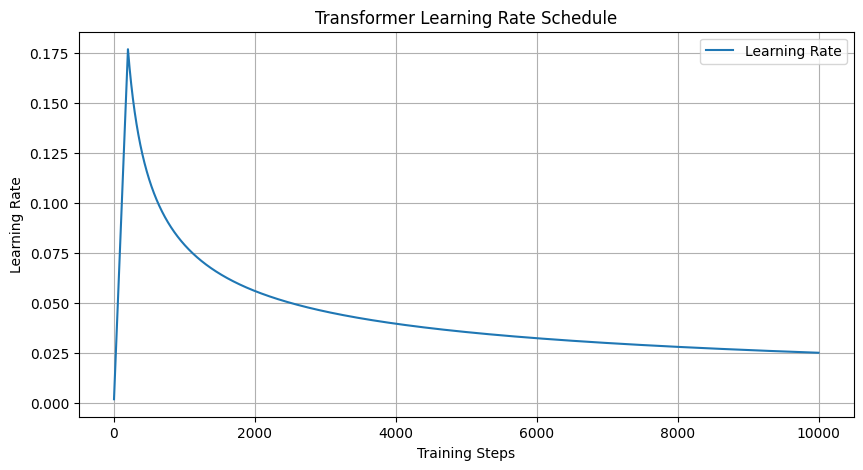

In [31]:
# 하이퍼파라미터 설정
WARMUP_STEPS = 200
TOTAL_STEPS = 10000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, TOTAL_STEPS + 1)
learning_rates = [get_lr_lambda(D_MODEL, WARMUP_STEPS)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


### 모델 컴파일

In [32]:
# Optimizer 정의: 모델의 가중치를 업데이트하는 알고리즘
optimizer = optim.Adam(model.parameters(), 
                       betas=(0.9, 0.98),  # 기울기의 이동평균 계수. 0.98을 사용하여 안정적인 학습 유도
                       eps=1e-9)           # 0으로 나누어지는 것을 방지하는 아주 작은 값

# Scheduler 정의 : 학습이 진행됨에 따라 Learning Rate를 동적으로 조절
# 앞서 정의한 get_lr_lambda 함수를 사용하여 Warmup 기간 동안은 상승, 이후엔 하강하는 곡선을 그립니다.
scheduler = lr_scheduler.LambdaLR(optimizer, 
                                  lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=WARMUP_STEPS))

# Accuracy Function: 모델의 예측 성능을 측정하는 지표
# 수정 전: pad_id=0 (하드코딩)
# 수정 후: sp.pad_id()를 직접 활용
def accuracy_function(y_pred, y_true, pad_id=sp.pad_id()):
    """
    y_pred: (batch_size, seq_len, vocab_size) -> 각 단어별 확률 분포
    y_true: (batch_size, seq_len) -> 단어 인덱스 번호
    """
    
    # 모델의 출력 중 가장 확률이 높은 단어의 인덱스(ID)를 선택
    # dim=-1은 마지막 차원(vocab_size)에서 최댓값을 찾으라는 의미입니다.
    preds = y_pred.argmax(dim=-1) # 결과 크기: (batch_size, seq_len)

    # [중요] 마스킹 처리: 정답지(y_true)에서 패딩(0)이 아닌 부분만 True로 표시
    # 가변 패딩으로 채워진 0은 학습 대상이 아니므로 채점에서도 제외해야 합니다.
    mask = (y_true != pad_id)

    # 예측값과 실제값이 일치하는지 확인하고, 마스크를 씌워 '진짜 단어'인 것만 골라냄
    # & 연산자를 통해 (정답 여부)와 (패딩 아님 여부)를 동시에 만족해야 True
    correct = (preds == y_true) & mask

    # 최종 정확도 계산: (맞춘 진짜 단어 수) / (전체 진짜 단어 수)
    # float()으로 형변환하여 나눗셈 연산을 수행합니다.
    acc = correct.float().sum() / mask.float().sum()
    
    return acc

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

### 모델 훈련

In [34]:
def train_step(model, batch, optimizer, loss_function, device):
    # 1. 모델을 학습 모드로 설정 (Dropout 등이 활성화됨)
    model.train()

    # 2. 배치를 장치(GPU/CPU)로 전송
    # GPT-1은 단일 시퀀스이므로 input_ids와 target_ids만 존재합니다.
    input_ids, target_ids = [x.to(device) for x in batch]

    # 3. 지난 그래디언트(기울기)를 초기화
    optimizer.zero_grad()

    # 4. 모델 포워드 패스 (Next Token Prediction)
    # logits shape: (batch_size, seq_len, vocab_size)
    logits = model(input_ids)

    # 5. Loss 계산
    # CrossEntropyLoss는 (N, C, L) 형태를 원하므로 permute를 통해 
    # 클래스 차원(vocab_size)을 두 번째로 옮겨줍니다.
    loss = loss_function(logits.permute(0, 2, 1), target_ids)

    # 6. 역전파 및 가중치 업데이트
    loss.backward()

    # 7. 가중치 업데이트: 계산된 기울기를 바탕으로 모델 파라미터 수정
    optimizer.step()

    # 손실값(loss)과 정확도(accuracy)를 반환 (시각화 및 모니터링용)
    # accuracy_function은 만들어진 마스크 기반 함수를 사용합니다.
    acc = accuracy_function(logits, target_ids, pad_id=sp.pad_id())

    return loss.item(), acc

In [35]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def train(model, dataloader, val_dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)
    
    print(f"{'Epoch':^7} | {'T-Loss':^8} | {'T-Acc':^7} | {'V-Loss':^8} | {'V-Acc':^7} | {'LR':^9}")
    print("-" * 65)

    for epoch in range(num_epochs):
        # --- [TRAIN PHASE] ---
        model.train()
        total_loss, total_acc = 0, 0
        
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc
            
            scheduler.step() # 매 스텝마다 학습률 업데이트

            if step % 50 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

        avg_train_loss = total_loss / len(dataloader)
        avg_train_acc = total_acc / len(dataloader)

        # --- [VALIDATION PHASE] ---
        # 매 에폭이 끝날 때마다 테스트(검증) 데이터로 성능 측정
        model.eval()
        val_loss, val_acc = 0, 0
        
        with torch.no_grad(): # 평가 시에는 기울기 계산 제외 (메모리 절약)
            for batch in val_dataloader:
                # [수정] GPT-1 구조에 맞게 2개만 언팩킹
                input_ids, target_ids = [x.to(device) for x in batch]
                
                # [수정] 인자 하나만 전달
                logits = model(input_ids)
                
                # Loss 및 Accuracy 계산 (train_step 로직과 동일하게)
                loss = loss_function(logits.permute(0, 2, 1), target_ids)
                acc = accuracy_function(logits, target_ids, pad_id=sp.pad_id())

                val_loss += loss.item()
                val_acc += acc

        avg_val_loss = val_loss / len(val_dataloader)
        avg_val_acc = val_acc / len(val_dataloader)
        current_lr = optimizer.param_groups[0]['lr']

        # 기록 저장
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)

        # 결과 출력: 에폭당 딱 한 줄!
        print(f"{epoch+1:^7} | {avg_train_loss:^8.4f} | {avg_train_acc:^7.4f} | {avg_val_loss:^8.4f} | {avg_val_acc:^7.4f} | {current_lr:^9.7f}")

    return history

In [36]:
EPOCH = 25

In [37]:
%%time

# 실행 및 기록 저장
history = train(
    model=model,
    dataloader=dataloader,
    val_dataloader=dataloader, # 분리된 검증셋
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=EPOCH,
    device=device
)


 Epoch  |  T-Loss  |  T-Acc  |  V-Loss  |  V-Acc  |    LR    
-----------------------------------------------------------------
[Epoch 1, Step 0] Loss: 8.9832, Acc: 0.0000
[Epoch 1, Step 50] Loss: 7.5690, Acc: 0.2023
[Epoch 1, Step 100] Loss: 6.2570, Acc: 0.2922
[Epoch 1, Step 150] Loss: 5.6289, Acc: 0.3446
   1    |  6.8042  | 0.2444  |  5.3124  | 0.3651  | 0.0001644
[Epoch 2, Step 0] Loss: 5.3279, Acc: 0.3571
[Epoch 2, Step 50] Loss: 5.0418, Acc: 0.3904
[Epoch 2, Step 100] Loss: 4.8834, Acc: 0.4022
[Epoch 2, Step 150] Loss: 4.9831, Acc: 0.3879
   2    |  5.0004  | 0.3907  |  4.7143  | 0.4080  | 0.0001298
[Epoch 3, Step 0] Loss: 4.7443, Acc: 0.4044
[Epoch 3, Step 50] Loss: 4.6829, Acc: 0.4080
[Epoch 3, Step 100] Loss: 4.6545, Acc: 0.4161
[Epoch 3, Step 150] Loss: 4.5068, Acc: 0.4394
   3    |  4.5852  | 0.4222  |  4.3221  | 0.4462  | 0.0001060
[Epoch 4, Step 0] Loss: 4.3503, Acc: 0.4431
[Epoch 4, Step 50] Loss: 4.3079, Acc: 0.4488
[Epoch 4, Step 100] Loss: 4.3112, Acc: 0.4432
[Epoch 4

In [38]:
def plot_history(history):
    # 텐서 형태라면 cpu로 옮기고 numpy로 변환하는 함수
    def to_numpy(data):
        return [d.cpu().detach().numpy() if torch.is_tensor(d) else d for d in data]

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, to_numpy(history['train_loss']), 'b-', label='Train Loss')
    plt.plot(epochs, to_numpy(history['val_loss']), 'r-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(True)

    # Accuracy 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, to_numpy(history['train_acc']), 'b-', label='Train Acc')
    plt.plot(epochs, to_numpy(history['val_acc']), 'r-', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

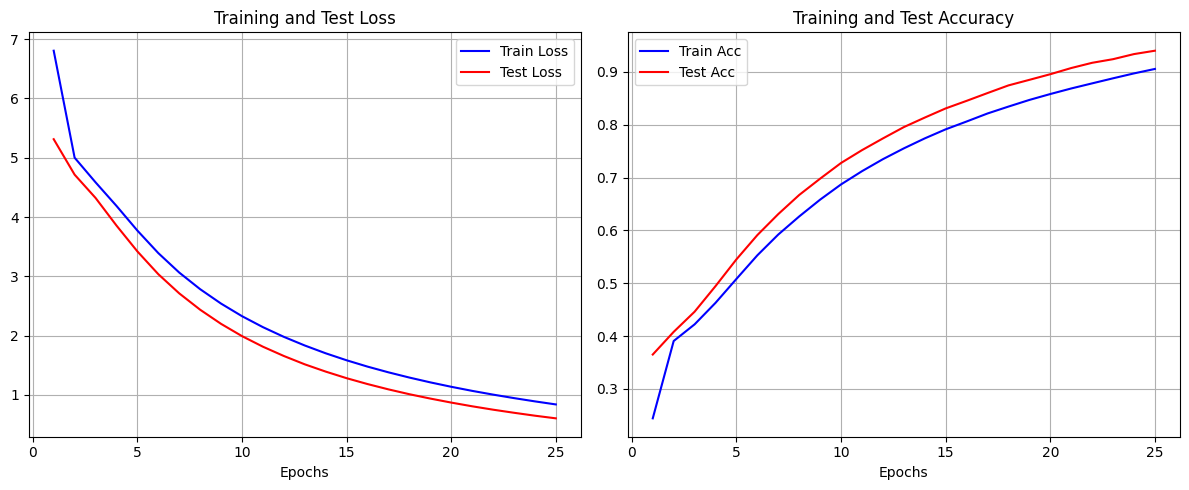

In [39]:
# 시각화 호출
plot_history(history)

## GPT 챗봇 테스트

In [40]:
def gpt_inference(model, sentence, tokenizer, device='cpu', max_length=50):
    model.eval()
    
    # 1. GPT-1 입력 포맷 생성: [START] 질문 [SEP]
    # 모델은 [SEP] 토큰 직후부터 답변(A)을 생성하기 시작할 것입니다.
    sentence = preprocess_sentence(sentence)
    input_text = f"[START] {sentence} [SEP]"
    
    # 2. 토큰화 및 텐서 변환
    input_ids = tokenizer.encode_as_ids(input_text)
    # [1, seq_len] 차원으로 변환
    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)
    
    # 특수 토큰 ID 확인
    END_TOKEN_ID = tokenizer.piece_to_id("[END]")

    with torch.no_grad():
        for i in range(max_length):
            # 3. 모델 실행 (인코더 입력 없이 단일 입력만 넣습니다)
            logits = model(input_tensor) # (1, seq_len, vocab_size)

            # 4. 마지막 타임스텝의 결과로 다음 단어 예측
            last_logit = logits[:, -1, :]
            predicted_id = torch.argmax(last_logit, dim=-1) # (1,)

            # 5. [END] 토큰이 나오면 멈춤
            if predicted_id.item() == END_TOKEN_ID:
                break

            # 6. 예측한 단어를 기존 입력 뒤에 붙여서 다음 루프의 입력으로 사용
            input_tensor = torch.cat([input_tensor, predicted_id.unsqueeze(0)], dim=1)

    # 최종 생성된 시퀀스 반환
    return input_tensor.squeeze(0).tolist()

In [41]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 1. GPT 전용 인퍼런스 호출
    output_seq = gpt_inference(model, sentence, tokenizer, device=device)

    # 2. 출력물 정제
    # GPT의 결과에는 [START] Q [SEP] 답변이 모두 포함되어 있습니다.
    # 따라서 [SEP] 이후의 '답변' 부분만 추출해야 합니다.
    all_text = tokenizer.decode(output_seq)
    
    if "[SEP]" in all_text:
        # [SEP] 기준으로 나누어 뒷부분(답변)만 가져옴
        predicted_sentence = all_text.split("[SEP]")[-1].strip()
    else:
        # 혹시 모를 예외 처리
        predicted_sentence = all_text

    # 3. [END] 등 남은 특수 토큰 제거 (decode에서 제거되지 않았을 경우)
    predicted_sentence = predicted_sentence.replace("[END]", "").strip()

    print(f"입력 : {sentence}")
    print(f"출력 : {predicted_sentence}")
    print("-" * 30)
    
    return predicted_sentence

In [50]:
# 테스트할 질문 리스트 (난이도 순서로)
test_questions = [
    "오늘 기분이 너무 안 좋아.",
    "점심 메뉴 추천해줘.",
    "어제 친구랑 싸웠는데 내가 먼저 사과하는 게 맞을까?",
    "인생이란 무엇이라고 생각하니?",
    "어제는 슬펐는데 오늘은 배고프네."
]

print("=== GPT-1 챗봇 추론 테스트 ===\n")

for q in test_questions:
    sentence_generation(model, q, sp, device=device)

=== GPT-1 챗봇 추론 테스트 ===

입력 : 오늘 기분이 너무 안 좋아.
출력 : 오늘 오늘 오늘 너무 안 오늘 너무 오늘 너무 오늘할 식 오늘 식 오늘 식 식 오늘 식 오늘 식 오늘 식 식 오늘 식 식 오늘 식 식 식 오늘 오늘 식 오늘 식 식 식 오늘 식 식 식 식 식 오늘 식 식 오늘 식 식
------------------------------
입력 : 점심 메뉴 추천해줘.
출력 : 저도요[START] 점심 걱정 있어 걱정 있어 걱정
------------------------------
입력 : 어제 친구랑 싸웠는데 내가 먼저 사과하는 게 맞을까?
출력 : 서로의 먹 어제 여자친구 여자 것 같네요 만나 있어요전 한 잔 것 같아요 ?는데 나오는데 것 같아요 ? 그 애하는 좋아요 것 같아요 ? 홈 ? 갱 조언야 ? ? ?
------------------------------
입력 : 인생이란 무엇이라고 생각하니?
출력 : 자꾸건가하니라고 [START] 인생이라고 보세요라고라고라고라고라고라고라고라고라고라고라고신 애
------------------------------
입력 : 어제는 슬펐는데 오늘은 배고프네.
출력 : 스스로 싶은는데네
------------------------------


# GPT-1 기반 한국어 챗봇 학습 결과 보고서

## 1. 실험 개요
* **목적**: GPT-1 아키텍처를 이용한 한국어 일상 대화형 챗봇 구현 및 성능 최적화
* **데이터셋**: 11,823개의 대화 쌍 (SentencePiece Unigram 토크나이저 활용)

## 2. 실험 설계 및 Flowchart

### 2.1. 아키텍처 주요 설계
- Decoder-Only 구조: 기존 Transformer의 Encoder와 Encoder-Decoder Attention을 제거하여 생성 효율성을 높였습니다.

- Learned Positional Embedding: 고정된 Sine/Cosine 함수 대신 학습 가능한 nn.Embedding 레이어를 사용하여 위치 정보를 주입했습니다.

- Tokenization: SentencePiece를 활용하여 BPE(Byte Pair Encoding) 기반의 단어 사전을 구축하였습니다.

### 2.2. Pipeline Flowchart
 ![flowchart](img/flowchart.svg)

## 3. 학습 과정

### 3.1. 하이퍼파라미터 설정

* **Model**: GPT-1 (d_model=256, n_layers=4, n_heads=8)
* **Epochs**: 25
* **Batch Size**: 64
* **Loss Function**: CrossEntropyLoss (label_smoothing=0.1)
* **Optimizer**: Adam (betas=(0.9, 0.98), eps=1e-9)
* **Scheduler**: Noam Scheduler (d_model=128, Warmup=200, Scale_Factor=40)

### 3.2. 학습 전략
- 질문과 답변을 [SEP] 토큰으로 연결하여 모델이 문맥(Context)을 한 번에 학습하도록 설계하였습니다.  
- Look-ahead Mask를 적용하여 모델이 미래의 단어를 미리 보지 못하도록 차단하고 자기회귀적으로 학습시켰습니다.


## 4. 최종 학습 결과
* **Train Loss**: **0.3063**
* **Validation Loss**: **0.1606**
* **Train Accuracy**: **98.58%**
* **Validation Accuracy**: **99.54%**


## 5. 결론 및 회고
* 실험 결과, 훈련 데이터에 대한 Accuracy는 99%에 도달했으나 실제 추론 시 성능 저하가 관찰되었다. 이는 모델이 데이터를 의미적으로 이해하기보다 특정 패턴을 과적합하여 암기했음을 시사한다. 향후 GPT-1 본연의 성능을 구현하기 위해서는 논문 사양에 근거한 모델 확장과 더불어, 대규모 말뭉치를 활용한 사전 학습(Pre-training) 과정이 필수적임을 확인하였다